In [1]:
import numpy as np
import pandas as pd
import os
import logging
from pyproj import Proj
from scipy.interpolate import PchipInterpolator
import math
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
from matplotlib.ticker import MultipleLocator
from pathlib import Path

def load_and_preprocess_csv(
    file_path, skiprows=100, skipfooter=100, flag=False, zone=52, window_size=200
):
    if flag:
        df = pd.read_csv(
            file_path,
            skiprows=skiprows,
            skipfooter=skipfooter,
            na_values=["", "nan", "NaN"],
            engine="python",
        ).fillna(0)
    else:
        df = pd.read_csv(
            file_path, skiprows=skiprows, skipfooter=skipfooter, engine="python"
        )

    df.columns = [
        "Time",
        "Accelerometer x", "Accelerometer y", "Accelerometer z",
        "Gyroscope x", "Gyroscope y", "Gyroscope z",
        "Magnetometer x", "Magnetometer y", "Magnetometer z",
        "Orientation x", "Orientation y", "Orientation z",
        "Pressure",
        "Latitude", "Longitude", "Altitude", "Speed_GPS",
    ]

    df["Time"] = pd.to_datetime(df["Time"], format="%Y-%m-%d %H:%M:%S.%f")
    start_dt = df["Time"].iloc[0]
    df["Elapsed Time"] = (df["Time"] - start_dt).dt.total_seconds()


    df["Acc_Norm"] = np.linalg.norm(
        df[["Accelerometer x", "Accelerometer y", "Accelerometer z"]].values, axis=1
    )
    df["Gyro_Norm"] = np.linalg.norm(
        df[["Gyroscope x", "Gyroscope y", "Gyroscope z"]].values, axis=1
    )
    
    return df
    
    
def llh_to_enu(df, flag, zone=52):
    if flag:
        valid_gps_mask = (
            df["Latitude"].notna()
            & df["Longitude"].notna()
            & (df["Latitude"].astype(str).str.strip() != "")
            & (df["Longitude"].astype(str).str.strip() != "")
        )
        valid_lat = pd.to_numeric(
            df.loc[valid_gps_mask, "Latitude"], errors="coerce"
        )
        valid_lon = pd.to_numeric(
            df.loc[valid_gps_mask, "Longitude"], errors="coerce"
        )
        final_mask = valid_lat.notna() & valid_lon.notna()
        valid_lat = valid_lat[final_mask].values
        valid_lon = valid_lon[final_mask].values
        if len(valid_lat) == 0:
            raise ValueError("유효한 GPS 데이터가 없습니다.")
        proj_enu = Proj(proj="utm", zone=zone, ellps="WGS84", south=False)
        e0, n0 = proj_enu(valid_lon[0], valid_lat[0])
        e_valid, n_valid = proj_enu(valid_lon, valid_lat)
        e_valid -= e0
        n_valid -= n0
        df["E"], df["N"] = np.nan, np.nan
        df.loc[valid_gps_mask, "E"] = e_valid
        df.loc[valid_gps_mask, "N"] = n_valid
        e = df["E"][df["E"].notna()].values
        n = df["N"][df["N"].notna()].values

    else:
        df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")
        df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")
        proj_enu = Proj(proj="utm", zone=zone, ellps="WGS84", south=False)
        e_all, n_all = proj_enu(df["Longitude"].values, df["Latitude"].values)
        e0, n0 = proj_enu(df["Longitude"].iloc[0], df["Latitude"].iloc[0])
        df["E"] = e_all - e0
        df["N"] = n_all - n0
        M = len(df)
        n_sec = M // 50
        e, n = [], []
        for i in range(n_sec):
            idx = min(i * 50 + 25, M - 1)
            e.append(df["E"].iloc[idx])
            n.append(df["N"].iloc[idx])
        e = np.array(e)
        n = np.array(n)

    # mask = mask_speed & mask_heading
    delta_e = np.diff(e)
    delta_n = np.diff(n)
    step = np.hypot(delta_e, delta_n)           # len = L-1

    # 3) 정지 구간
    stop_mask = step < 0.05

    # 4) 최종 마스크 (모두 길이 L-1)
    mask = (~stop_mask)
    gps_idx_all = np.arange(1, len(e))
    bad_idx = gps_idx_all[~mask]

    print(f"총 GPS 샘플: {len(e)}, 이상치 GPS 샘플: {len(bad_idx)}")

    # -------------------------------------------------------
    # (4) 센서데이터 블록 drop (1Hz GPS → 50Hz 센서)
    # -------------------------------------------------------
    drop_idx = []
    for gi in bad_idx:
        start = gi * 50
        end = (gi + 1) * 50
        drop_idx.extend(range(start, min(end, len(df))))
    df = df.drop(drop_idx).reset_index(drop=True)

    if flag:
        # --- NaN 있는 경우: 유효 GPS만 모아서 다시 ENU trajectory 계산 ---
        valid_gps_mask = (
            df["Latitude"].notna()
            & df["Longitude"].notna()
            & (df["Latitude"].astype(str).str.strip() != "")
            & (df["Longitude"].astype(str).str.strip() != "")
        )
        valid_lat = pd.to_numeric(
            df.loc[valid_gps_mask, "Latitude"], errors="coerce"
        )
        valid_lon = pd.to_numeric(
            df.loc[valid_gps_mask, "Longitude"], errors="coerce"
        )
        final_mask = valid_lat.notna() & valid_lon.notna()
        valid_lat = valid_lat[final_mask].values
        valid_lon = valid_lon[final_mask].values

        if len(valid_lat) < 2:
            raise ValueError("유효 GPS가 drop 이후 2개 미만으로 남음")

        proj_enu = Proj(proj="utm", zone=zone, ellps="WGS84", south=False)
        e0, n0 = proj_enu(valid_lon[0], valid_lat[0])
        e_valid, n_valid = proj_enu(valid_lon, valid_lat)
        e, n = e_valid - e0, n_valid - n0

    else:
        # --- NaN 없는 경우: 센서 50Hz 중간 샘플 뽑기 ---
        M = len(df)
        n_sec = M // 50
        e, n = [], []
        for i in range(n_sec):
            idx = min(i * 50 + 25, M - 1)
            e.append(df["E"].iloc[idx])
            n.append(df["N"].iloc[idx])
        e, n = np.array(e), np.array(n)

    # # -------------------------------------------------------
    # # (5) 초기 heading 정렬 + 보간
    # # -------------------------------------------------------
    dx0, dy0 = e[1] - e[0], n[1] - n[0]
    theta0 = math.atan2(dy0, dx0)
    R0 = np.array(
        [
            [math.cos(-theta0), -math.sin(-theta0)],
            [math.sin(-theta0), math.cos(-theta0)],
        ]
    )
    coords = np.vstack([e - e[0], n - n[0]])
    rotated = R0 @ coords
    e_corr, n_corr = rotated[0], rotated[1]

    return e_corr, n_corr, df
 

def interpol_vAndh(e, n):
    
    deg_threshold = 3.0
    
    # 1Hz (실제로는 1초 간격 점)에서 heading 계산
    delta_e = np.diff(e)
    delta_n = np.diff(n)

    disp_1hz = np.hypot(delta_e, delta_n)          # 1초 변위 (m)
    heading_1hz = np.arctan2(delta_n, delta_e)     # 1Hz heading (rad)
    

    # 길이 맞추기: disp_1hz는 len=L-1, heading_1hz도 len=L-1
    N = len(heading_1hz)
    t = np.arange(N, dtype=float)  # 0..N-1 (초 index)

    # 10Hz 타임라인: 1초당 10개 샘플
    t_new = np.linspace(0.0, N - 1, (N - 1) * 10 + 1)

    # heading은 unwrap한 뒤 보간 (중요!)
    heading_unwrap = np.unwrap(heading_1hz)

    p_disp = PchipInterpolator(t, disp_1hz)
    p_head = PchipInterpolator(t, heading_unwrap)

    disp_10Hz = p_disp(t_new)
    head_10Hz = p_head(t_new)

    # 다시 dh 계산: 10Hz에서의 heading 변화량(라디안/샘플)
    dh_10Hz = np.diff(head_10Hz)
    # 1초 누적 heading change (rad per 1s)
    dh_1s_10Hz = np.convolve(dh_10Hz, np.ones(10), mode="valid")
    
    # dh_1s_10Hz_deg = np.degrees(dh_1s_10Hz)
    # dh_1s_10Hz_deg[np.abs(dh_1s_10Hz_deg) <= 1] = 0
    # dh_1s_10Hz = np.radians(dh_1s_10Hz_deg)
    
    
    # dh는 diff로 길이가 1 줄어드니까 disp_10Hz도 맞춰줌(선택)
    disp_10Hz = disp_10Hz[1:]
    head_10Hz = head_10Hz[1:]

    return disp_10Hz, dh_1s_10Hz


def makeXY(df, v_10Hz, dh_50Hz, window_size):
    stride = 5
    sensor_cols = [
        "Accelerometer x",
        "Accelerometer y",
        "Accelerometer z",
        "Gyroscope x",
        "Gyroscope y",
        "Gyroscope z",
        "Acc_Norm",
        "Gyro_Norm",
    ]

    values = df[sensor_cols].to_numpy()   # (N, num_features)
    N, num_features = values.shape

    # -------------------------
    # 1) X 만들기 (stride에 따라 분기)
    # -------------------------
    if stride == 1:
        # sliding_window_view로 오버헤드 최소화
        # 결과 shape: (N - window_size + 1, window_size, num_features)
        windows = sliding_window_view(values, (window_size, num_features))
        X = windows[:, 0, :, :]  # (N, window_size, F)
    else:
        # 기존 코드 그대로 (stride=5 등)
        X_list = []
        for i in range(0, N - window_size + 1, stride):
            window = values[i : i + window_size]   # (window_size, num_features)
            X_list.append(window)
        X = np.stack(X_list, axis=0)           # (num_windows, window_size, num_features)

    Y_v = []
    Y_dh = []

    offsets = [0, 10, 20, 30]  # 1초 간격 (10Hz 기준)
    #offsets = [0, 50, 100, 150]
    for i in range(len(v_10Hz) - max(offsets)):
        # v: 1초 단위 4개를 합
        Y_v.append(
            v_10Hz[i + offsets[0]]
            + v_10Hz[i + offsets[1]]
            + v_10Hz[i + offsets[2]]
            + v_10Hz[i + offsets[3]]
        )
        
    # -------------------------
    # 3) Y_dh
    # -------------------------
    Y_dh = []
    for i in range(0, len(dh_50Hz) - window_size + 1, stride):
        dh_sum = np.sum(dh_50Hz[i : i + window_size])
        Y_dh.append(dh_sum)

    # -------------------------
    # 4) 길이 맞추기
    # -------------------------
    min_len = min(len(X), len(Y_v), len(Y_dh))
    X = X[:min_len]
    Y_v = Y_v[:min_len]
    Y_dh = Y_dh[:min_len]

    Y = np.stack([Y_v, Y_dh], axis=1)

    return X, Y


def heading_ref(df, use_bias_snap=True):
    fs = 50.0
    dt = 1.0 / fs
    
    gx = df["Gyroscope x"].to_numpy(dtype=float, copy=True)
    gy = df["Gyroscope y"].to_numpy(dtype=float, copy=True)
    gz = df["Gyroscope z"].to_numpy(dtype=float, copy=True)
    
    qx = df["Orientation x"].to_numpy(dtype=float, copy=True)
    qy = df["Orientation y"].to_numpy(dtype=float, copy=True)
    qz = df["Orientation z"].to_numpy(dtype=float, copy=True)
    
    # =========================
    # 1. qw 복원
    # =========================
    qw_sq = 1.0 - (qx**2 + qy**2 + qz**2)
    qw_sq = np.clip(qw_sq, 0.0, None)
    qw = np.sqrt(qw_sq)
    
    # =========================
    # 2. 쿼터니언 부호 연속성 보정
    # =========================
    for i in range(1, len(qw)):
        dot = (
            qw[i-1] * qw[i]
            + qx[i-1] * qx[i]
            + qy[i-1] * qy[i]
            + qz[i-1] * qz[i]
        )
        if dot < 0:
            qw[i] = -qw[i]
            qx[i] = -qx[i]
            qy[i] = -qy[i]
            qz[i] = -qz[i]

    # =========================
    # 3. pitch 계산
    # =========================
    pitch = np.arctan2(
        2.0 * (qw * qx + qy * qz),
        1.0 - 2.0 * (qx * qx + qy * qy)
    )

    # =========================
    # 4. pitch 제거하여 gyro 보정
    # =========================
    gyro_corr = np.zeros((len(gx), 3))

    for i in range(len(gx)):
        c = np.cos(pitch[i])
        s = np.sin(pitch[i])

        R_inv_pitch = np.array([
            [1, 0, 0],
            [0, c, -s],
            [0, s,  c]
        ])

        g = np.array([gx[i], gy[i], gz[i]])
        gyro_corr[i] = R_inv_pitch @ g

    gz_corr = gyro_corr[:, 2]

    # =========================
    # 5. 초기 적분
    # =========================
    theta_z = np.cumsum(gz_corr) * dt
    theta_z_deg = np.degrees(theta_z)

    # =========================
    # 6. 90도 배수 기반 bias 보정
    # =========================
    if use_bias_snap:
        observed_total_deg = theta_z_deg[-1]
        #snapped_total_deg = 90.0 * np.round(observed_total_deg / 90.0)
        snapped_total_deg = -1890
        total_time = len(gz_corr) * dt
        bias_deg_per_sec = (observed_total_deg - snapped_total_deg) / total_time
        bias_rad_per_sec = np.radians(bias_deg_per_sec)

        print(f"observed_total_deg = {observed_total_deg:.3f}")
        print(f"snapped_total_deg  = {snapped_total_deg:.3f}")
        print(f"estimated_bias     = {bias_deg_per_sec:.6f} deg/s")

        gz_corr = gz_corr - bias_rad_per_sec

        # 보정 후 다시 적분
        theta_z = np.cumsum(gz_corr) * dt
        theta_z_deg = np.degrees(theta_z)

    dh_50hz = np.diff(theta_z)
    return dh_50hz

총 GPS 샘플: 298, 이상치 GPS 샘플: 0
observed_total_deg = -1876.643
snapped_total_deg  = -1890.000
estimated_bias     = 0.044954 deg/s


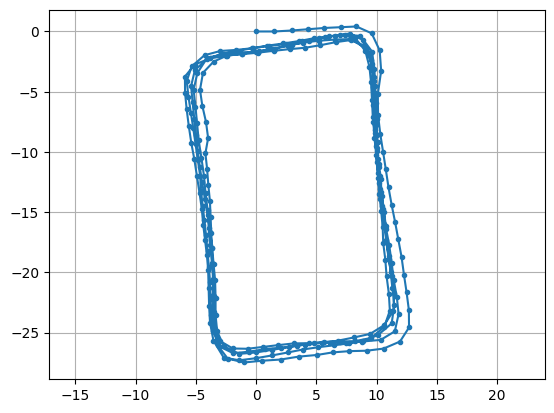

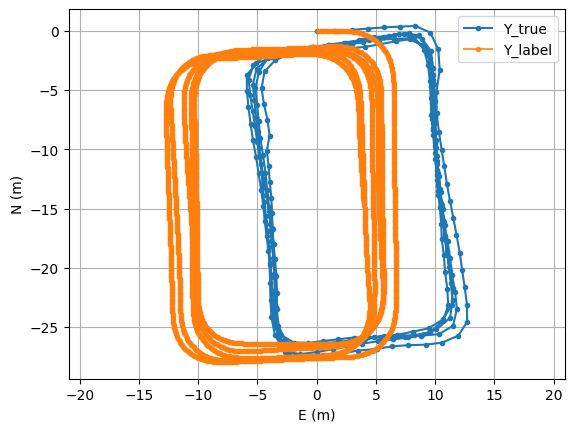

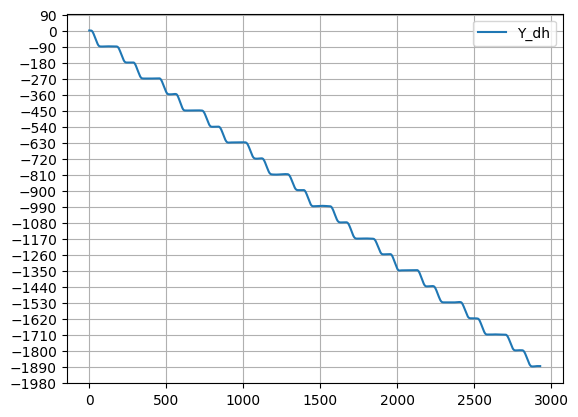

In [2]:
BASE_DIR = os.getcwd()
WINDOW_SIZE = 200

DATA_CONFIG = {
    "looking_left01.csv": {"skiprows": 300, "flag": False, "zone": 52, "expected_total_deg": 671.600},
    "looking_left02.csv": {"skiprows": 150, "flag": False, "zone": 52, "expected_total_deg": 1710},
    "looking_left03.csv": {"skiprows": 250, "flag": False, "zone": 52, "expected_total_deg": 2430},
    "looking_left04.csv": {"skiprows": 150, "flag": False, "zone": 52, "expected_total_deg": 2430},
    "looking_left05.csv": {"skiprows": 300, "flag": True, "zone": 52, "expected_total_deg": 4950},
    
    "looking_right01.csv": {"skiprows": 200, "flag": False, "zone": 52, "expected_total_deg": -1070},
    "looking_right02.csv": {"skiprows": 100, "flag": False, "zone": 52, "expected_total_deg": -2430},
    "looking_right03.csv": {"skiprows": 200, "flag": False, "zone": 52, "expected_total_deg": -2790},
    "looking_right04.csv": {"skiprows": 350, "flag": True, "zone": 52, "expected_total_deg": -5220},
    
    "swing_left01_ref.csv": {"skiprows": 350, "flag": True, "zone": 52, "expected_total_deg": 1980},
    "swing_right01_ref.csv": {"skiprows": 350, "flag": True, "zone": 52, "expected_total_deg": -1890},
    
    "calling_left01_ref.csv": {"skiprows": 350, "flag": True, "zone": 52, "expected_total_deg": 1890},
    "calling_right01_ref.csv": {"skiprows": 350, "flag": True, "zone": 52, "expected_total_deg": -1890},
}

DATA_FILE_PATH_LIST = [
        # os.path.join(BASE_DIR, "data", "tester1", "learn_looking", "looking_left01.csv"), # 2분 
        # os.path.join(BASE_DIR, "data", "tester1", "learn_looking", "looking_left02.csv"), # 3분 
        # os.path.join(BASE_DIR, "data", "tester1", "learn_looking", "looking_left03.csv"), # 5분
        # os.path.join(BASE_DIR, "data", "tester1", "learn_looking", "looking_left04.csv"), # 5분 
        # os.path.join(BASE_DIR, "data", "tester1", "learn_looking", "looking_left05.csv"), # 10분 
        
        # #보고걷기 우회전 
        # os.path.join(BASE_DIR, "data", "tester1", "learn_looking", "looking_right01.csv"), # 3분
        # os.path.join(BASE_DIR, "data", "tester1", "learn_looking", "looking_right02.csv"), # 4분
        # os.path.join(BASE_DIR, "data", "tester1", "learn_looking", "looking_right03.csv"), # 5분
        # os.path.join(BASE_DIR, "data", "tester1", "learn_looking", "looking_right04.csv"), # 10분 
        
        
        # os.path.join(BASE_DIR, "data", "tester1", "learn_swing", "swing_left01_ref.csv"), # 5분 
        # os.path.join(BASE_DIR, "data", "tester1", "learn_swing", "swing_right01_ref.csv"), # 5분 
        # os.path.join(BASE_DIR, "data", "tester1", "learn_calling", "calling_left01_ref.csv"), # 5분 
        os.path.join(BASE_DIR, "data", "tester1", "learn_calling", "calling_right01_ref.csv"), # 5분 
]

fname = Path(DATA_FILE_PATH_LIST[0]).name
opts = DATA_CONFIG.get(fname)
df1 = load_and_preprocess_csv(DATA_FILE_PATH_LIST[0], skiprows=350).copy()

zone = 52
flag = True

e, n, df = llh_to_enu(df1, flag, zone)
v_10hz, dh_10hz = interpol_vAndh(e, n)

dh_50Hz = heading_ref(df)

X, Y = makeXY(df, v_10hz, dh_50Hz, window_size=200)

window_size = 200

y_e = []
y_n = []
dx = 0.0
dy = 0.0
heading = 0

stride = 5

plt.plot(e, n, ".-")
plt.axis("equal")
plt.grid()
plt.show()

for v, h in zip(Y[:, 0], Y[:, 1]):
    heading += h * (stride / window_size)
    dx += (v * (stride / window_size)) * np.cos(heading)
    dy += (v * (stride / window_size)) * np.sin(heading)
    y_e.append(dx)
    y_n.append(dy)

plt.plot(e, n, ".-", label="Y_true")
plt.plot(y_e, y_n, ".-", label="Y_label", alpha=0.8)
plt.xlabel("E (m)")
plt.ylabel("N (m)")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()

plt.plot(
    np.cumsum(np.degrees(Y[:, 1])) * (stride / window_size), label="Y_dh"
)
plt.gca().yaxis.set_major_locator(MultipleLocator(90))
plt.grid()
plt.legend()
plt.show()

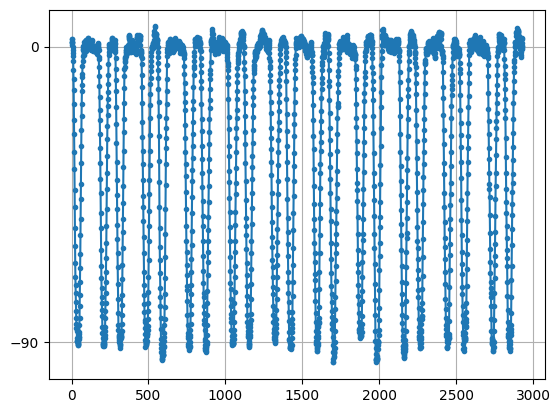

In [3]:
plt.plot(np.degrees(Y[:,1]), '.-')
plt.grid()
plt.gca().yaxis.set_major_locator(MultipleLocator(90))